# *Data Loading*

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv("../data/dataset_with_weather_and_noise.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (25000, 44)


,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delayed,...,holiday_or_weekend_transit_flag,holiday_proximity_feature,api_temperature,api_humidity,api_wind_speed,precipitation,bad_weather_flag_api,temperature,humidity,wind_speed
0,250.99,amazon logistics,automobile parts,ev bike,standard,west,clear,244.719006,47.540697,no,...,0,1,33.122327,75.752202,17.619252,3.506765,0,32.483571,74.097849,17.056317
1,250.99,amazon logistics,clothing,bike,express,central,clear,85.025123,46.143220,yes,...,0,1,29.729640,95.602409,15.867221,2.943648,0,29.308678,94.778295,15.486040
2,250.99,amazon logistics,clothing,van,same day,north,clear,293.126234,31.971948,yes,...,1,8,33.545242,54.693465,11.853310,1.892765,0,33.238443,56.395895,13.558508
3,250.99,amazon logistics,cosmetics,ev bike,two day,central,stormy,107.903116,8.234676,no,...,0,2,37.927240,91.773339,8.088707,2.332062,1,37.615149,88.800189,7.938182
4,250.99,amazon logistics,cosmetics,ev van,two day,east,foggy,211.123548,7.186863,no,...,1,1,29.547111,72.695976,4.071856,1.645159,1,28.829233,72.374135,2.726783


In [3]:
safe_features_reg = [
    "delivery_partner",
    "package_type",
    "vehicle_type",
    "delivery_mode",
    "region",
    "weather_condition",
    "distance_km",
    "package_weight_kg",

    # TIME FEATURES
    "order_hour",
    "order_day",
    "is_weekend",

    # HOLIDAY FEATURES (SAFE)
    "holiday_or_weekend_transit_flag",
    "holiday_count_transit"
]

In [4]:
target_reg = "delivery_time_hours_recon"

In [5]:
X = df[safe_features_reg]
y = df[target_reg]

In [6]:
X = pd.get_dummies(X, drop_first=True)

In [7]:
import joblib

joblib.dump(X.columns, "../models/regression_feature_columns.pkl")

['../models/regression_feature_columns.pkl']

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Random Forest Regressor

In [9]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(X_train, y_train)

rf_pred = rf_reg.predict(X_test)

XGBoost Regressor

In [10]:
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_reg.fit(X_train, y_train)

xgb_pred = xgb_reg.predict(X_test)

Model Evaluation

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(y_test, pred, name):

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    print(f"\n{name}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

evaluate_model(y_test, rf_pred, "Random Forest Regressor")
evaluate_model(y_test, xgb_pred, "XGBoost Regressor")


Random Forest Regressor
MAE: 0.384364427362414
RMSE: 0.4883071436721141
R2 Score: 0.9650239417016553

XGBoost Regressor
MAE: 0.3710433193790574
RMSE: 0.47450129072759656
R2 Score: 0.966973731697501


In [12]:
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "MAE": [
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, xgb_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ],
    "R2 Score": [
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred)
    ]
})

print(results)

           Model       MAE      RMSE  R2 Score
0  Random Forest  0.384364  0.488307  0.965024
1        XGBoost  0.371043  0.474501  0.966974


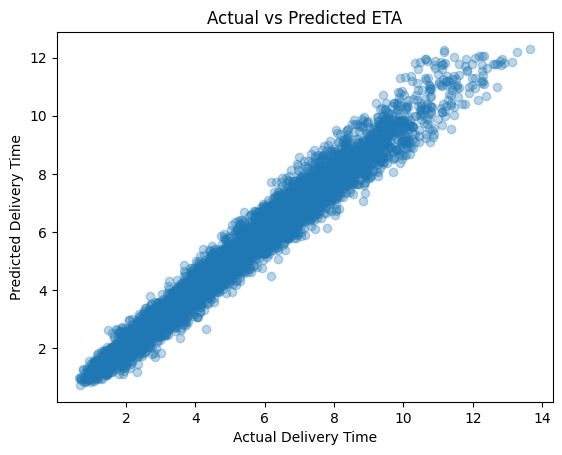

In [13]:
import matplotlib.pyplot as plt

plt.scatter(y_test, xgb_pred, alpha=0.3)
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted ETA")
plt.show()

| Model         | MAE       | RMSE      | R²        |
| ------------- | --------- | --------- | --------- |
| Random Forest | 0.385     | 0.490     | 0.965     |
| XGBoost       | **0.371** | **0.475** | **0.967** |


XGBoost outperformes compared to Random Forest

Checking for overfitting:

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Training predictions
rf_train_pred = rf_reg.predict(X_train)

print("Random Forest Train Metrics")
print("MAE:", mean_absolute_error(y_train, rf_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, rf_train_pred)))
print("R2:", r2_score(y_train, rf_train_pred))


print("\nRandom Forest Test Metrics")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2:", r2_score(y_test, rf_pred))

Random Forest Train Metrics
MAE: 0.14276093767968398
RMSE: 0.1839430077949367
R2: 0.9951300891558099

Random Forest Test Metrics
MAE: 0.384364427362414
RMSE: 0.4883071436721141
R2: 0.9650239417016553


In [15]:
# Training predictions
xgb_train_pred = xgb_reg.predict(X_train)

print("XGBoost Train Metrics")
print("MAE:", mean_absolute_error(y_train, xgb_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, xgb_train_pred)))
print("R2:", r2_score(y_train, xgb_train_pred))


print("\nXGBoost Test Metrics")
print("MAE:", mean_absolute_error(y_test, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))
print("R2:", r2_score(y_test, xgb_pred))

XGBoost Train Metrics
MAE: 0.3137206259507694
RMSE: 0.40172035988293714
R2: 0.9767725181584106

XGBoost Test Metrics
MAE: 0.3710433193790574
RMSE: 0.47450129072759656
R2: 0.966973731697501


In [16]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_reg,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross-validation R2 scores:", scores)
print("Average CV R2:", scores.mean())

Cross-validation R2 scores: [0.9645661  0.96411218 0.96552411 0.9637116  0.96448985]
Average CV R2: 0.9644807673715265


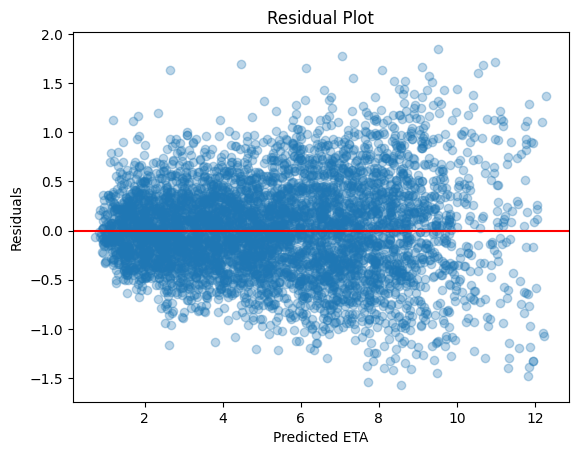

In [17]:
import matplotlib.pyplot as plt

residuals = y_test - xgb_pred

plt.scatter(xgb_pred, residuals, alpha=0.3)
plt.axhline(0, color="red")
plt.xlabel("Predicted ETA")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Model Downloading :

In [18]:
import joblib
import os

# create models folder in parent directory
os.makedirs("../models", exist_ok=True)

# save models
joblib.dump(rf_reg, "../models/random_forest_regressor.pkl")
joblib.dump(xgb_reg, "../models/xgboost_regressor.pkl")

print("Regression models saved successfully!")

Regression models saved successfully!
